# EXP-004 — Classifiers on 19-Feature FFT+UMAP Matrix
Logistic Regression and Random Forest on the full pipeline features
(StandardScaler → FFT 16 + UMAP 3 = 19 features) from EXP-002.
Direct comparison with EXP-003 (raw 16 features) to measure the feature engineering lift.

In [1]:
import sys
sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

from src.beed.config import CLASS_LABELS, DATA_PROCESSED, FIGURES, RANDOM_STATE

FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_theme(style='whitegrid')
print('Ready.')

Ready.


## 1. Load pre-built feature matrices (from EXP-002)

In [2]:
train_df = pd.read_parquet(DATA_PROCESSED / 'train_features.parquet')
val_df   = pd.read_parquet(DATA_PROCESSED / 'val_features.parquet')
test_df  = pd.read_parquet(DATA_PROCESSED / 'test_features.parquet')

feature_cols = [c for c in train_df.columns if c != 'y']

X_train = train_df[feature_cols]
y_train = train_df['y']
X_val   = val_df[feature_cols]
y_val   = val_df['y']
X_test  = test_df[feature_cols]
y_test  = test_df['y']

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Features: {feature_cols}')

Train: (5600, 19)  Val: (800, 19)  Test: (1600, 19)
Features: ['Fp1_fft', 'Fp2_fft', 'F3_fft', 'F4_fft', 'C3_fft', 'C4_fft', 'P3_fft', 'P4_fft', 'O1_fft', 'O2_fft', 'F7_fft', 'F8_fft', 'T3_fft', 'T4_fft', 'T5_fft', 'T6_fft', 'umap_1', 'umap_2', 'umap_3']


## 2. Train classifiers

In [3]:
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE,
    C=1.0,
)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    lr.fit(X_train, y_train)
print('Logistic Regression fitted.')

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
print('Random Forest fitted.')

Logistic Regression fitted.


Random Forest fitted.


## 3. Evaluate on validation set

In [4]:
label_names = [CLASS_LABELS[i] for i in sorted(CLASS_LABELS)]

for name, clf in [('Logistic Regression', lr), ('Random Forest', rf)]:
    preds = clf.predict(X_val)
    print(f'=== {name} — Validation ===')
    print(classification_report(y_val, preds, target_names=label_names))
    print()

=== Logistic Regression — Validation ===
                precision    recall  f1-score   support

       Healthy       1.00      0.97      0.98       200
         Focal       0.71      0.65      0.68       200
   Generalized       0.56      0.66      0.60       200
Seizure Events       0.49      0.46      0.47       200

      accuracy                           0.68       800
     macro avg       0.69      0.68      0.69       800
  weighted avg       0.69      0.68      0.69       800


=== Random Forest — Validation ===
                precision    recall  f1-score   support

       Healthy       1.00      0.97      0.98       200
         Focal       0.92      0.89      0.90       200
   Generalized       0.80      0.91      0.85       200
Seizure Events       0.85      0.79      0.82       200

      accuracy                           0.89       800
     macro avg       0.89      0.89      0.89       800
  weighted avg       0.89      0.89      0.89       800




## 4. Confusion matrices — validation set

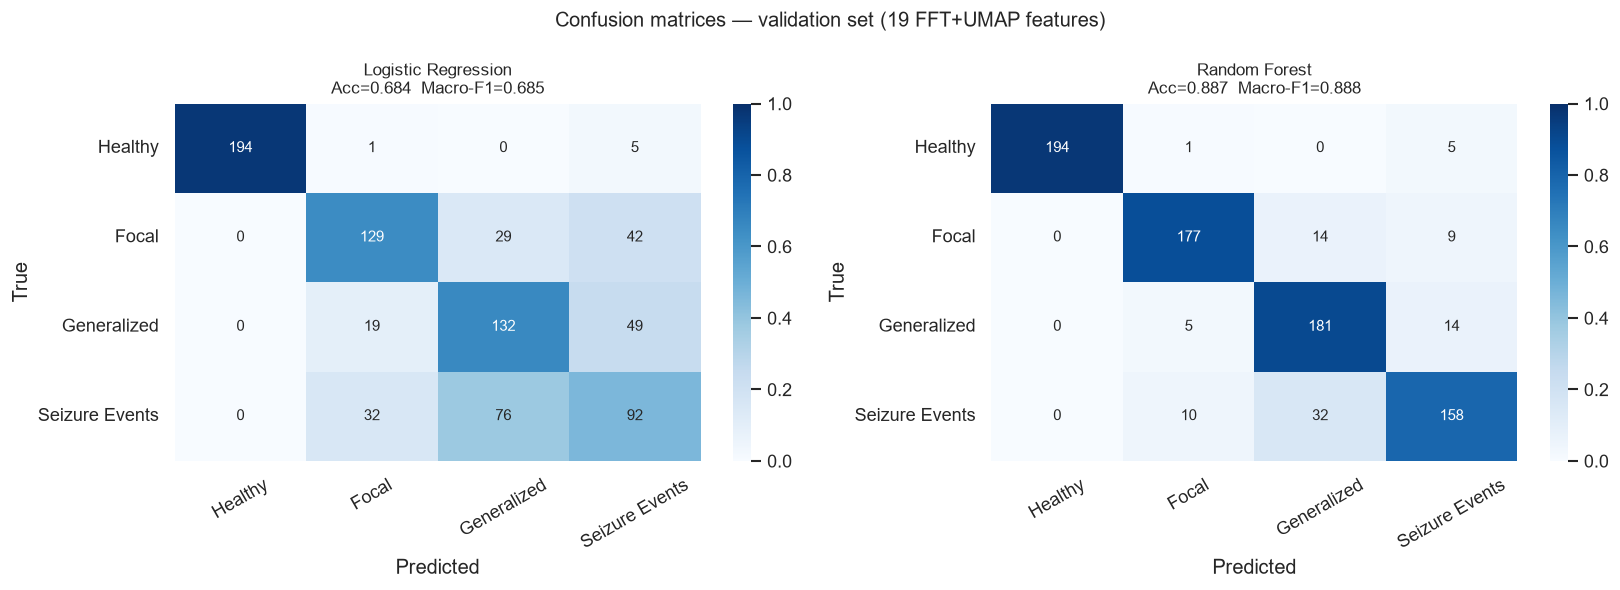

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, clf) in zip(axes, [('Logistic Regression', lr), ('Random Forest', rf)]):
    preds = clf.predict(X_val)
    cm = confusion_matrix(y_val, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=cm, fmt='d', ax=ax,
        xticklabels=label_names, yticklabels=label_names,
        cmap='Blues', vmin=0, vmax=1,
        annot_kws={'size': 9},
    )
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average='macro')
    ax.set_title(f'{name}\nAcc={acc:.3f}  Macro-F1={f1:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Confusion matrices — validation set (19 FFT+UMAP features)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '15_exp004_confusion_val.png', bbox_inches='tight')
plt.show()

## 5. Evaluate on test set

In [6]:
for name, clf in [('Logistic Regression', lr), ('Random Forest', rf)]:
    preds = clf.predict(X_test)
    print(f'=== {name} — Test ===')
    print(classification_report(y_test, preds, target_names=label_names))
    print()

=== Logistic Regression — Test ===
                precision    recall  f1-score   support

       Healthy       1.00      0.98      0.99       400
         Focal       0.70      0.68      0.69       400
   Generalized       0.59      0.69      0.63       400
Seizure Events       0.52      0.45      0.48       400

      accuracy                           0.70      1600
     macro avg       0.70      0.70      0.70      1600
  weighted avg       0.70      0.70      0.70      1600


=== Random Forest — Test ===
                precision    recall  f1-score   support

       Healthy       1.00      0.99      0.99       400
         Focal       0.89      0.87      0.88       400
   Generalized       0.80      0.90      0.85       400
Seizure Events       0.85      0.79      0.82       400

      accuracy                           0.89      1600
     macro avg       0.89      0.89      0.89      1600
  weighted avg       0.89      0.89      0.89      1600




## 6. Confusion matrices — test set

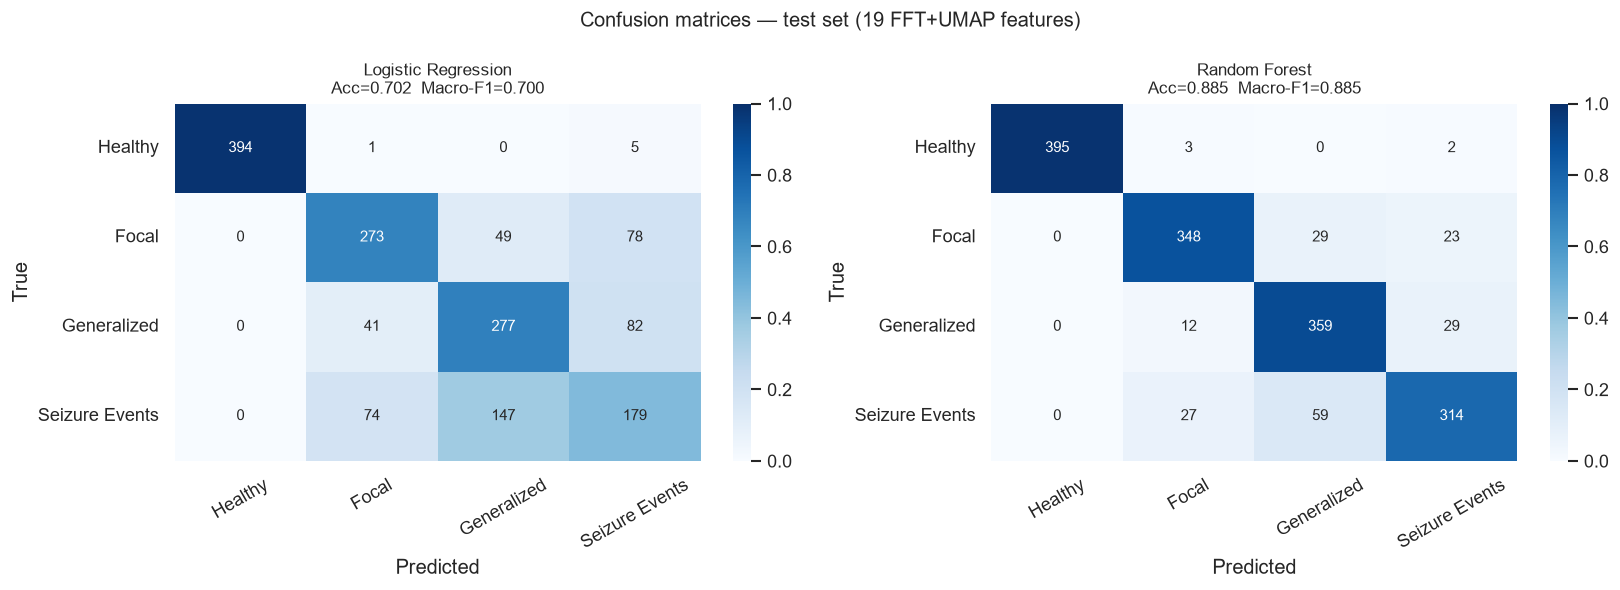

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, clf) in zip(axes, [('Logistic Regression', lr), ('Random Forest', rf)]):
    preds = clf.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=cm, fmt='d', ax=ax,
        xticklabels=label_names, yticklabels=label_names,
        cmap='Blues', vmin=0, vmax=1,
        annot_kws={'size': 9},
    )
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro')
    ax.set_title(f'{name}\nAcc={acc:.3f}  Macro-F1={f1:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Confusion matrices — test set (19 FFT+UMAP features)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '16_exp004_confusion_test.png', bbox_inches='tight')
plt.show()

## 7. Feature importances — Random Forest

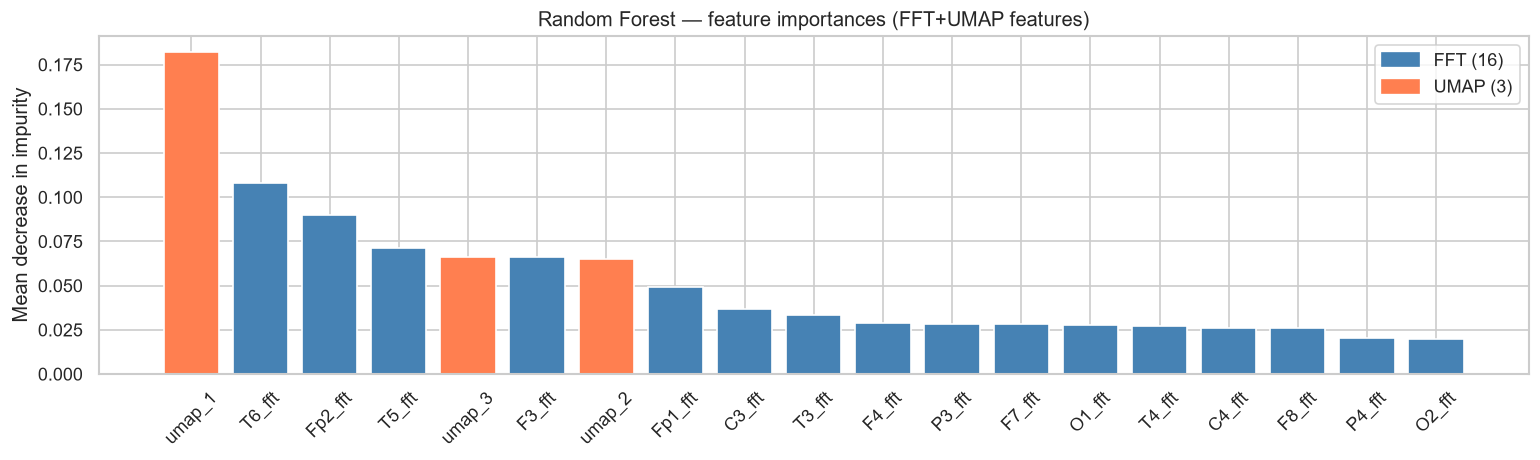

Top 5 features by importance:
umap_1     0.181951
T6_fft     0.107735
Fp2_fft    0.089980
T5_fft     0.071341
umap_3     0.066421


In [8]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

colors = ['coral' if c.startswith('umap_') else 'steelblue' for c in importances.index]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(importances.index, importances.values, color=colors)
ax.set_ylabel('Mean decrease in impurity')
ax.set_title('Random Forest — feature importances (FFT+UMAP features)')
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='FFT (16)'),
    Patch(color='coral', label='UMAP (3)'),
])
plt.tight_layout()
plt.savefig(FIGURES / '17_exp004_rf_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features by importance:')
print(importances.head().to_string())

## 8. EXP-003 vs EXP-004 comparison

In [9]:
# Build EXP-004 results
rows = []
for name, clf in [('Logistic Regression', lr), ('Random Forest', rf)]:
    for split_name, X_s, y_s in [('val', X_val, y_val), ('test', X_test, y_test)]:
        preds = clf.predict(X_s)
        rows.append({
            'exp': 'EXP-004',
            'model': name,
            'split': split_name,
            'accuracy': round(accuracy_score(y_s, preds), 4),
            'macro_f1': round(f1_score(y_s, preds, average='macro'), 4),
            'weighted_f1': round(f1_score(y_s, preds, average='weighted'), 4),
        })

results_004 = pd.DataFrame(rows)
results_004.to_csv(DATA_PROCESSED / 'exp004_results.csv', index=False)
print('EXP-004 results:')
print(results_004.to_string(index=False))

EXP-004 results:
    exp               model split  accuracy  macro_f1  weighted_f1
EXP-004 Logistic Regression   val    0.6837    0.6851       0.6851
EXP-004 Logistic Regression  test    0.7019    0.7001       0.7001
EXP-004       Random Forest   val    0.8875    0.8880       0.8880
EXP-004       Random Forest  test    0.8850    0.8850       0.8850


In [10]:
# Load EXP-003 results for comparison
results_003 = pd.read_csv(DATA_PROCESSED / 'exp003_baseline_results.csv')
results_003.insert(0, 'exp', 'EXP-003')

combined = pd.concat([results_003, results_004], ignore_index=True)
test_cmp = combined[combined['split'] == 'test'][['exp', 'model', 'accuracy', 'macro_f1']]
test_cmp = test_cmp.sort_values(['model', 'exp']).reset_index(drop=True)
print('Test-set comparison:')
print(test_cmp.to_string(index=False))

Test-set comparison:
    exp               model  accuracy  macro_f1
EXP-003 Logistic Regression    0.4606    0.4678
EXP-004 Logistic Regression    0.7019    0.7001
EXP-003       Random Forest    0.9537    0.9538
EXP-004       Random Forest    0.8850    0.8850


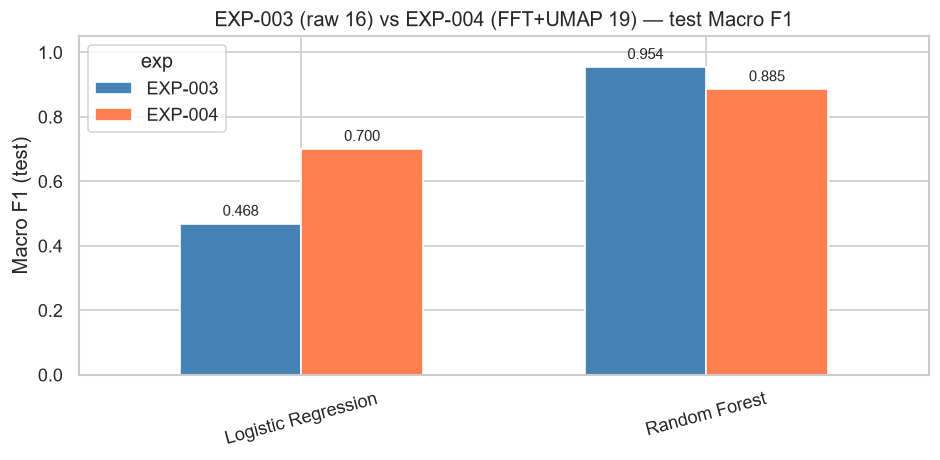

In [11]:
# Side-by-side bar chart: EXP-003 vs EXP-004, test macro-F1
pivot = test_cmp.pivot(index='model', columns='exp', values='macro_f1')

fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white', width=0.6)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Macro F1 (test)')
ax.set_title('EXP-003 (raw 16) vs EXP-004 (FFT+UMAP 19) — test Macro F1')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / '18_exp003_vs_exp004.png', bbox_inches='tight')
plt.show()

## 9. Summary

In [12]:
print('=== EXP-004 Summary ===')
print('Feature set : StandardScaler → FFT (16) + UMAP (3) = 19 features')
print(f'Train / Val / Test : {X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]} samples')
print()
for _, row in results_004[results_004['split'] == 'test'].iterrows():
    print(f"{row['model']:25s}  test acc={row['accuracy']:.4f}  macro-F1={row['macro_f1']:.4f}")
print()
print('Delta vs EXP-003 (raw 16 features):')
for model in ['Logistic Regression', 'Random Forest']:
    f1_003 = results_003[(results_003['model'] == model) & (results_003['split'] == 'test')]['macro_f1'].values[0]
    f1_004 = results_004[(results_004['model'] == model) & (results_004['split'] == 'test')]['macro_f1'].values[0]
    delta = f1_004 - f1_003
    sign = '+' if delta >= 0 else ''
    print(f'  {model:25s}  Δmacro-F1 = {sign}{delta:.4f}')

=== EXP-004 Summary ===
Feature set : StandardScaler → FFT (16) + UMAP (3) = 19 features
Train / Val / Test : 5600 / 800 / 1600 samples

Logistic Regression        test acc=0.7019  macro-F1=0.7001
Random Forest              test acc=0.8850  macro-F1=0.8850

Delta vs EXP-003 (raw 16 features):
  Logistic Regression        Δmacro-F1 = +0.2323
  Random Forest              Δmacro-F1 = -0.0688
